# Experiment 3

# Regression Analysis using Machine Learning Algorithms

### Objective

To implement and compare various regression algorithms for predicting Loan Sanction Amount using a real-world dataset.

### Algorithms Used

- Linear Regression
- Ridge Regression
- Lasso Regression
- Elastic Net Regression
- Decision Tree Regression
- Random Forest Regression
- Support Vector Regression (SVR)

### Evaluation Metrics

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score
- Cross Validation
- Training Time
- Prediction Time

### Dataset

Loan Sanction Prediction Dataset

In [1]:
import os
import sys

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt


# Add src path

sys.path.append("../src")


from preprocessing import preprocess_data


from regression import (
    train_regression,
    tune_regression_model,
    get_coefficients
)


from validation import (
    compare_cross_validation
)


from metrics import (
    regression_metrics,
    compare_regression_models
)


from timing import (
    compare_training_prediction_time
)


from visualization import (
    plot_target_distribution,
    plot_feature_vs_target,
    plot_actual_vs_predicted,
    plot_residuals,
    plot_coefficients,
    plot_training_validation_error,
    plot_regression_scores,
    plot_regression_time,
    plot_correlation_heatmap
)


from eda import (
    perform_regression_eda
)


import warnings

warnings.filterwarnings("ignore")

In [2]:
DATA_PATH="../datasets/raw/train.csv"


df=pd.read_csv(DATA_PATH)


df.head()

,Customer ID,Name,Gender,Age,Income (USD),Income Stability,Profession,Type of Employment,Location,Loan Amount Request (USD),...,Credit Score,No. of Defaults,Has Active Credit Card,Property ID,Property Age,Property Type,Property Location,Co-Applicant,Property Price,Loan Sanction Amount (USD)
0,C-36995,Frederica Shealy,F,56,1933.05,Low,Working,Sales staff,Semi-Urban,72809.58,...,809.44,0,NaN,746,1933.05,4,Rural,1,119933.46,54607.18
1,C-33999,America Calderone,M,32,4952.91,Low,Working,NaN,Semi-Urban,46837.47,...,780.40,0,Unpossessed,608,4952.91,2,Rural,1,54791.00,37469.98
2,C-3770,Rosetta Verne,F,65,988.19,High,Pensioner,NaN,Semi-Urban,45593.04,...,833.15,0,Unpossessed,546,988.19,2,Urban,0,72440.58,36474.43
3,C-26480,Zoe Chitty,F,65,NaN,High,Pensioner,NaN,Rural,80057.92,...,832.70,1,Unpossessed,890,NaN,2,Semi-Urban,1,121441.51,56040.54
4,C-23459,Afton Venema,F,31,2614.77,Low,Working,High skill tech staff,Semi-Urban,113858.89,...,745.55,1,Active,715,2614.77,4,Semi-Urban,1,208567.91,74008.28


In [3]:
print("Dataset Shape:")
print(df.shape)


print("\nColumns:")
print(df.columns.tolist())


print("\nData Types:")
df.info()

Dataset Shape:
(30000, 24)

Columns:
['Customer ID', 'Name', 'Gender', 'Age', 'Income (USD)', 'Income Stability', 'Profession', 'Type of Employment', 'Location', 'Loan Amount Request (USD)', 'Current Loan Expenses (USD)', 'Expense Type 1', 'Expense Type 2', 'Dependents', 'Credit Score', 'No. of Defaults', 'Has Active Credit Card', 'Property ID', 'Property Age', 'Property Type', 'Property Location', 'Co-Applicant', 'Property Price', 'Loan Sanction Amount (USD)']

Data Types:
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer ID                  30000 non-null  str    
 1   Name                         30000 non-null  str    
 2   Gender                       29947 non-null  str    
 3   Age                          30000 non-null  int64  
 4   Income (USD)                 25424 non-null  float64
 5   Income Stabi

In [4]:
df.describe()

,Age,Income (USD),Loan Amount Request (USD),Current Loan Expenses (USD),Dependents,Credit Score,No. of Defaults,Property ID,Property Age,Property Type,Co-Applicant,Property Price,Loan Sanction Amount (USD)
count,30000.000000,2.542400e+04,30000.000000,29828.000000,27507.000000,28297.000000,30000.000000,30000.000000,2.515000e+04,30000.000000,30000.000000,3.000000e+04,29660.000000
mean,40.092300,2.630574e+03,88826.333855,400.936876,2.253027,739.885381,0.193933,501.934700,2.631119e+03,2.460067,-4.743867,1.317597e+05,47649.342208
std,16.045129,1.126272e+04,59536.949605,242.545375,0.951162,72.163846,0.395384,288.158086,1.132268e+04,1.118562,74.614593,9.354955e+04,48221.146686
min,18.000000,3.777000e+02,6048.240000,-999.000000,1.000000,580.000000,0.000000,1.000000,3.777000e+02,1.000000,-999.000000,-9.990000e+02,-999.000000
25%,25.000000,1.650457e+03,41177.755000,247.667500,2.000000,681.880000,0.000000,251.000000,1.650450e+03,1.000000,1.000000,6.057216e+04,0.000000
50%,40.000000,2.222435e+03,75128.075000,375.205000,2.000000,739.820000,0.000000,504.000000,2.223250e+03,2.000000,1.000000,1.099936e+05,35209.395000
75%,55.000000,3.090593e+03,119964.605000,521.292500,3.000000,799.120000,0.000000,751.000000,3.091408e+03,3.000000,1.000000,1.788807e+05,74261.250000
max,65.000000,1.777460e+06,621497.820000,3840.880000,14.000000,896.260000,1.000000,999.000000,1.777460e+06,4.000000,1.000000,1.077967e+06,481907.320000


In [5]:
TARGET="Loan Sanction Amount (USD)"

REGRESSION EDA
Shape: (30000, 24)

Missing Values:
Customer ID                       0
Name                              0
Gender                           53
Age                               0
Income (USD)                   4576
Income Stability               1683
Profession                        0
Type of Employment             7270
Location                          0
Loan Amount Request (USD)         0
Current Loan Expenses (USD)     172
Expense Type 1                    0
Expense Type 2                    0
Dependents                     2493
Credit Score                   1703
No. of Defaults                   0
Has Active Credit Card         1566
Property ID                       0
Property Age                   4850
Property Type                     0
Property Location               356
Co-Applicant                      0
Property Price                    0
Loan Sanction Amount (USD)      340
dtype: int64

Duplicate Rows: 0

Statistics:
                Age  Income (USD)  Loan 

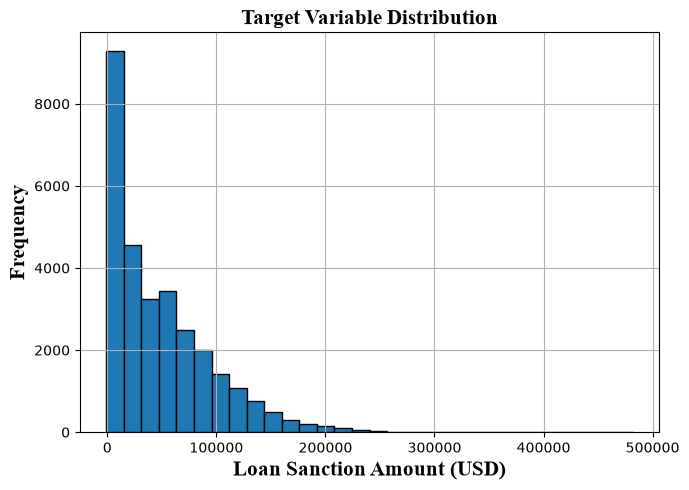

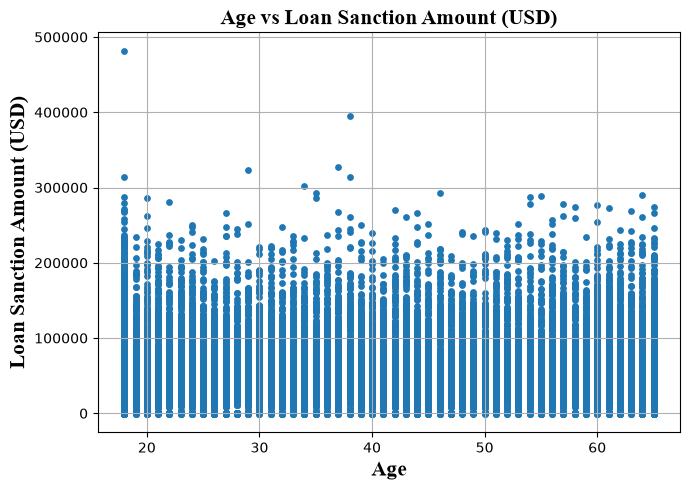

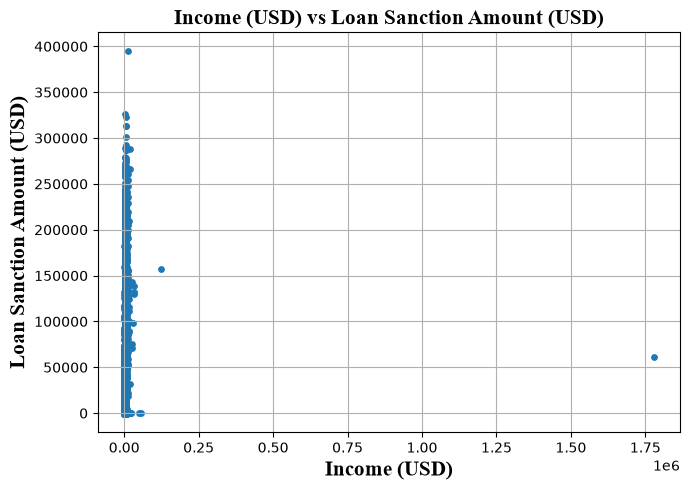

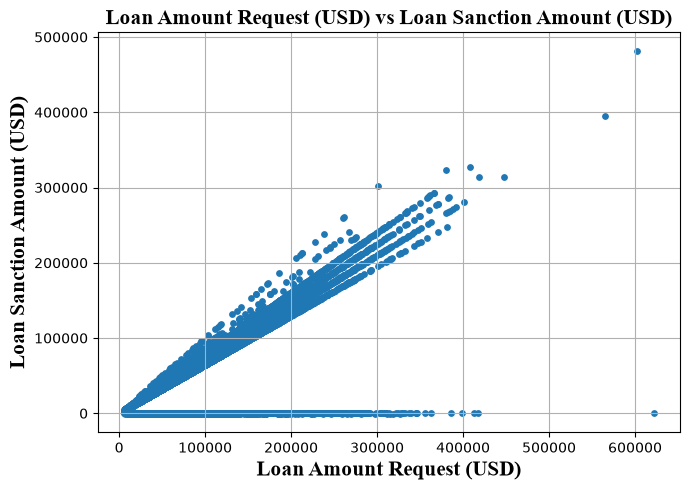

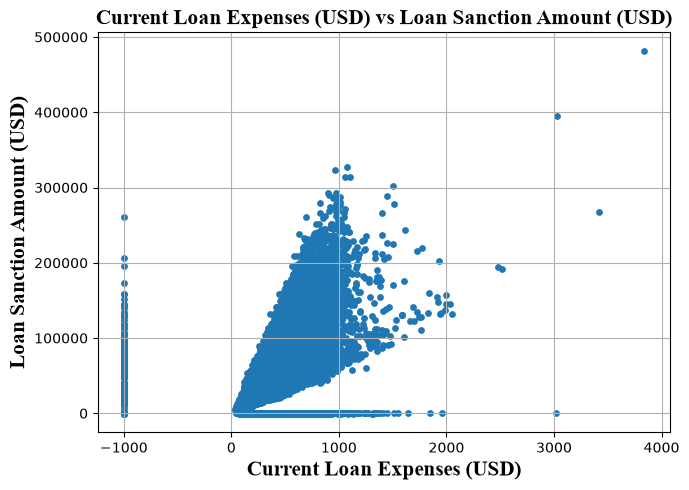

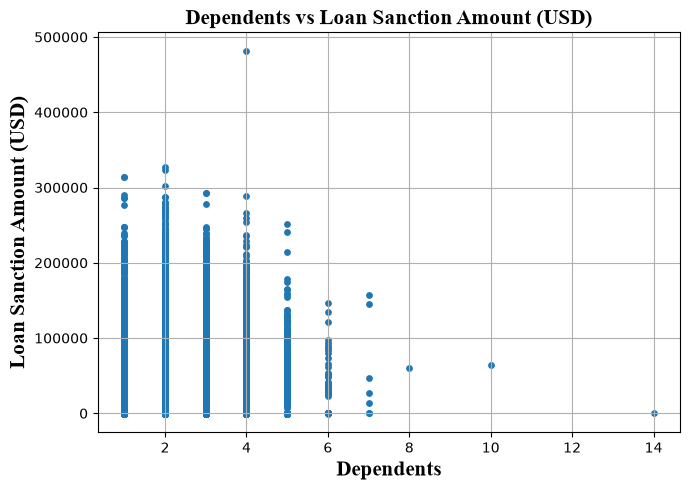

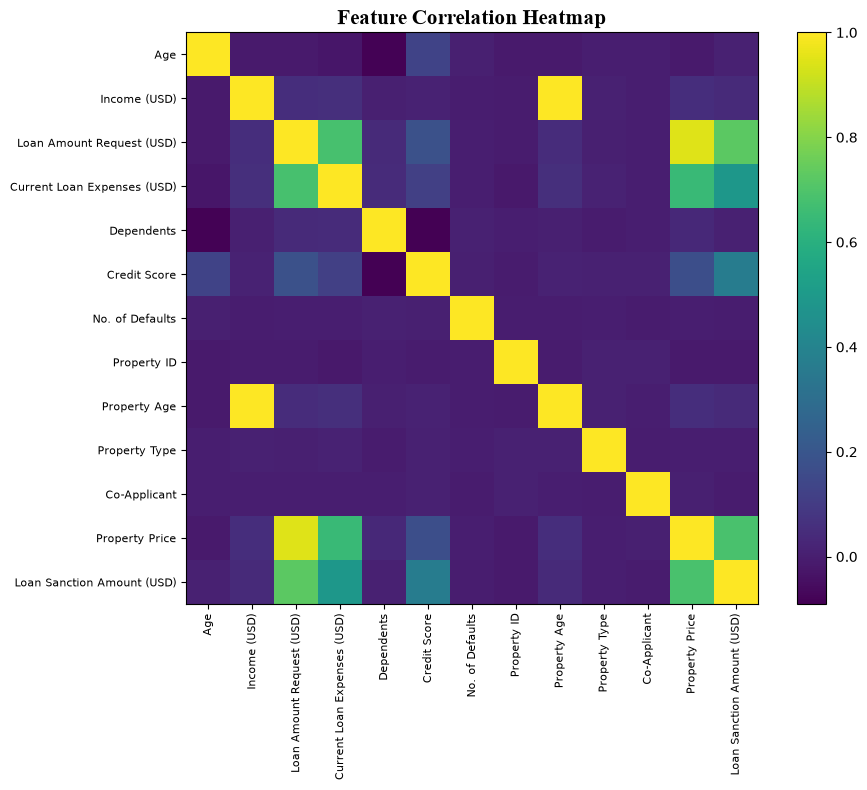

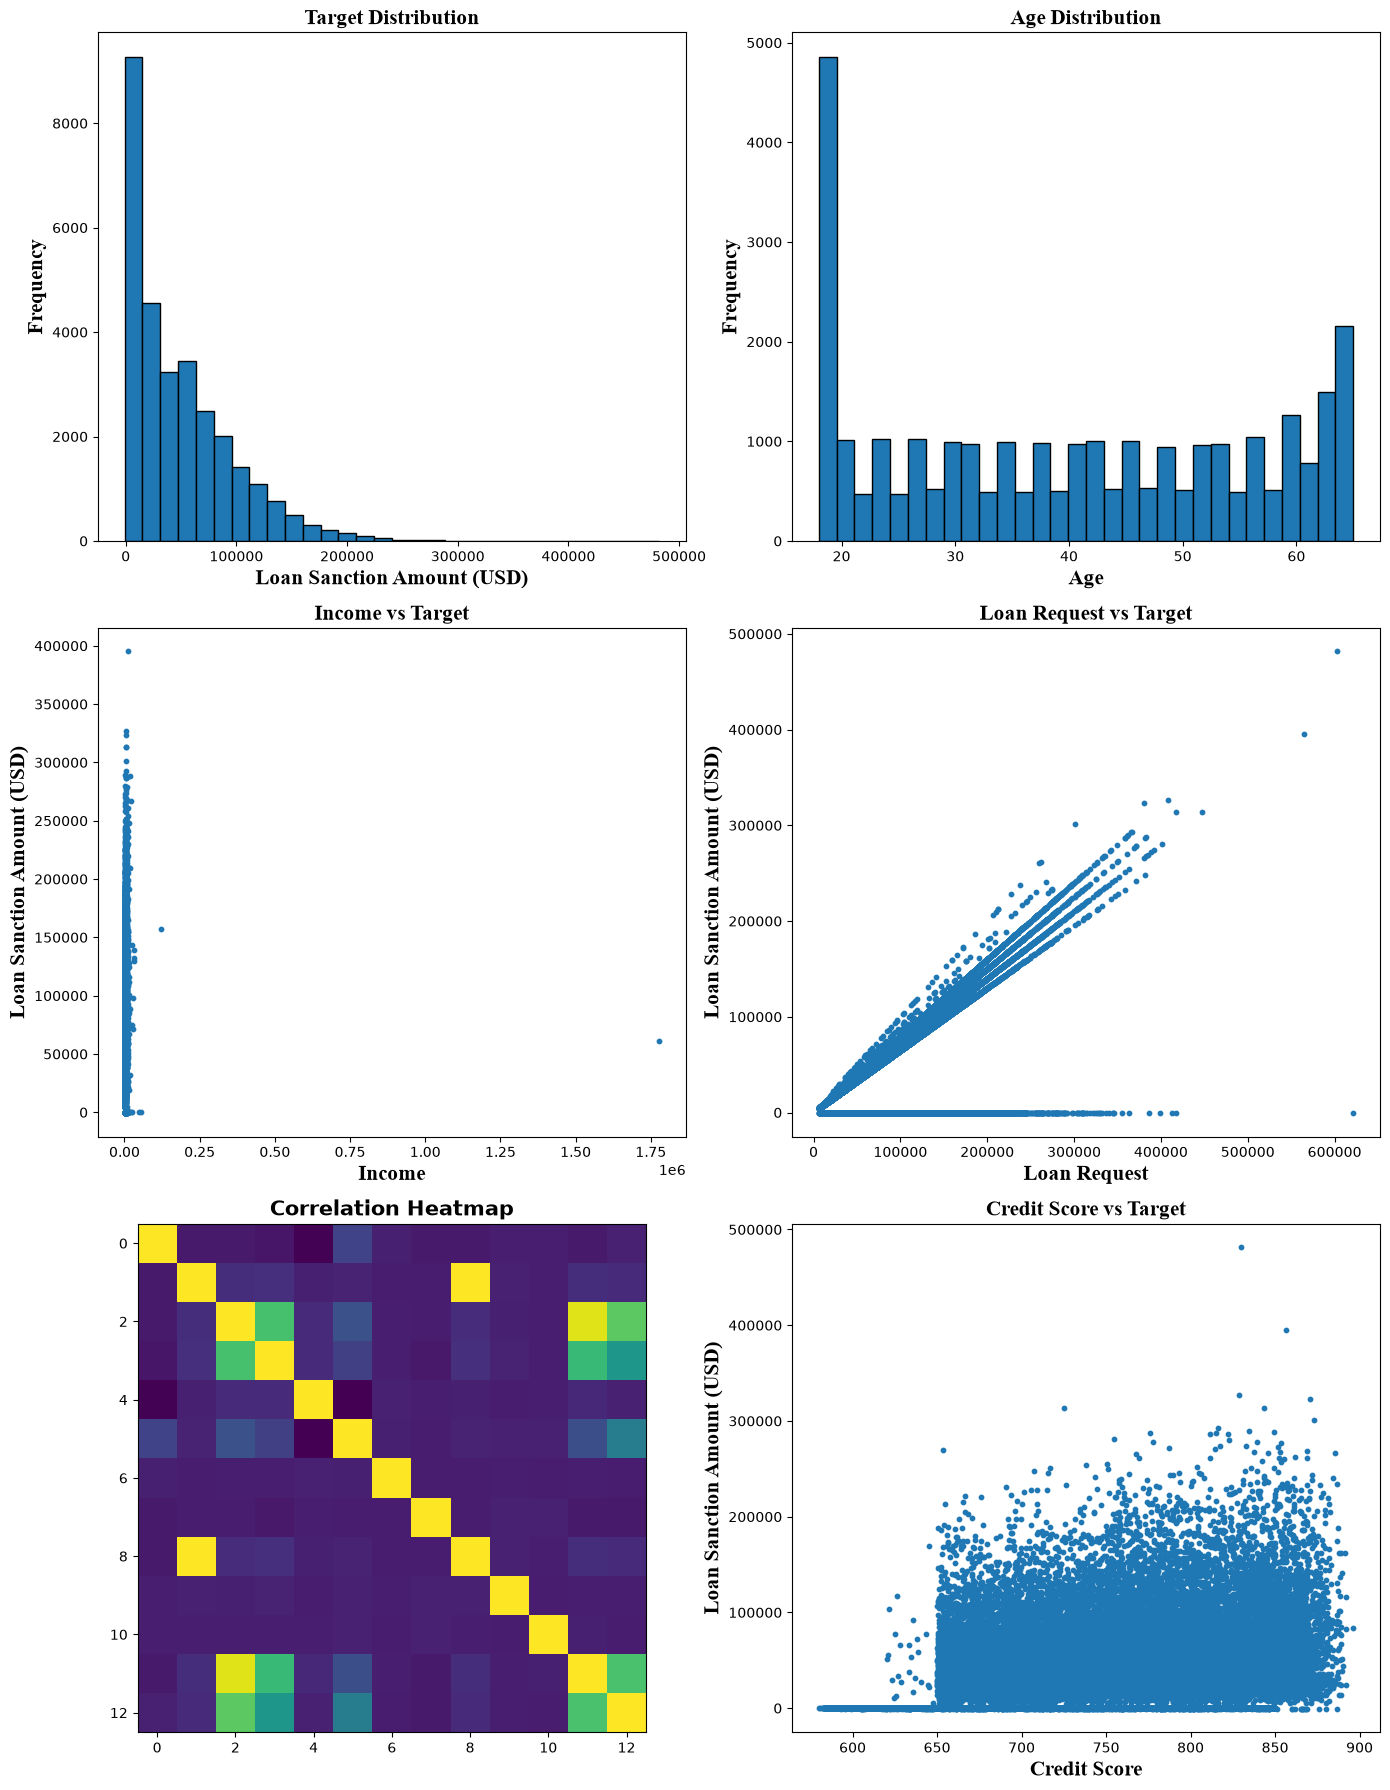


Target Correlation:
Loan Sanction Amount (USD)     1.000000
Loan Amount Request (USD)      0.726408
Property Price                 0.687181
Current Loan Expenses (USD)    0.485070
Credit Score                   0.369450
Income (USD)                   0.038157
Property Age                   0.037796
Dependents                     0.009088
Age                            0.008112
Property Type                  0.001984
No. of Defaults               -0.004330
Co-Applicant                  -0.006945
Property ID                   -0.009751
Name: Loan Sanction Amount (USD), dtype: float64


In [6]:
perform_regression_eda(
    df,
    TARGET,
    save_dir="../figures"
)

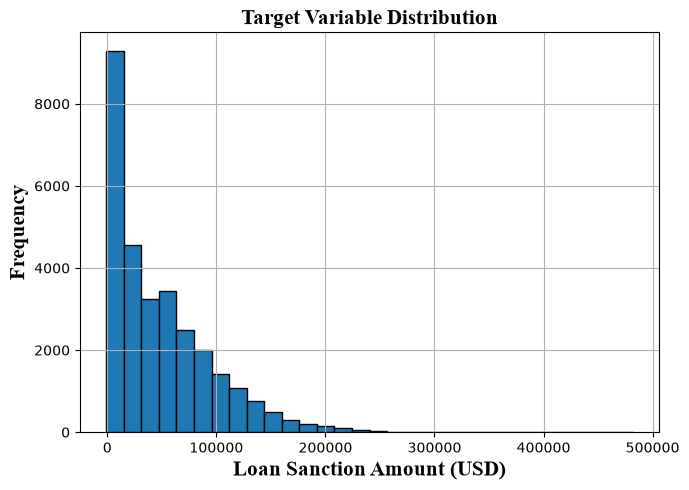

In [7]:
plot_target_distribution(
    df[TARGET],
    TARGET
)

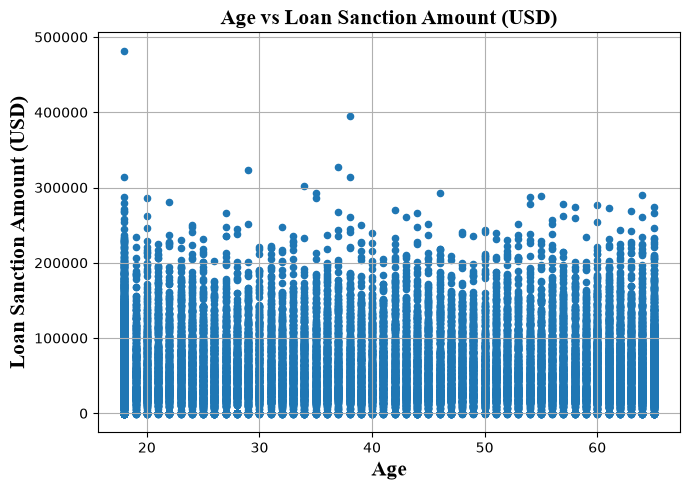

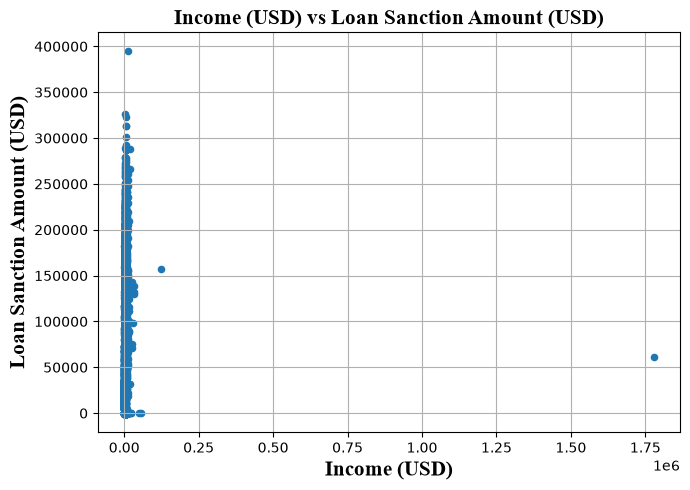

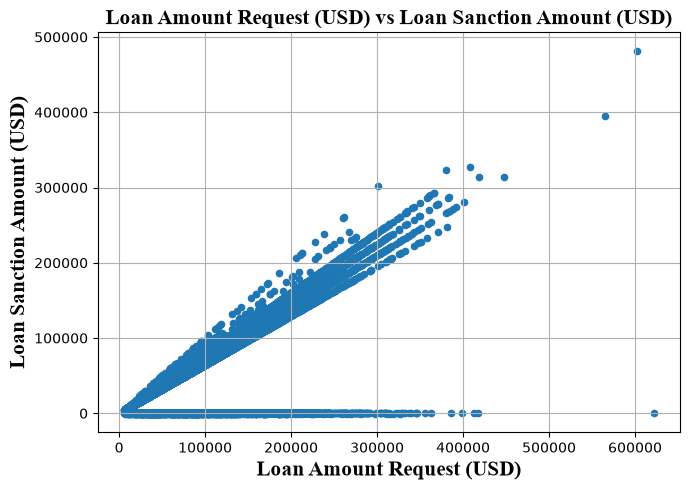

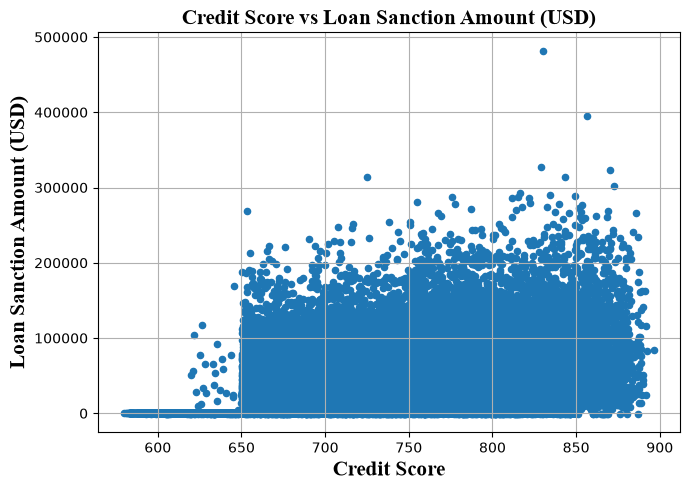

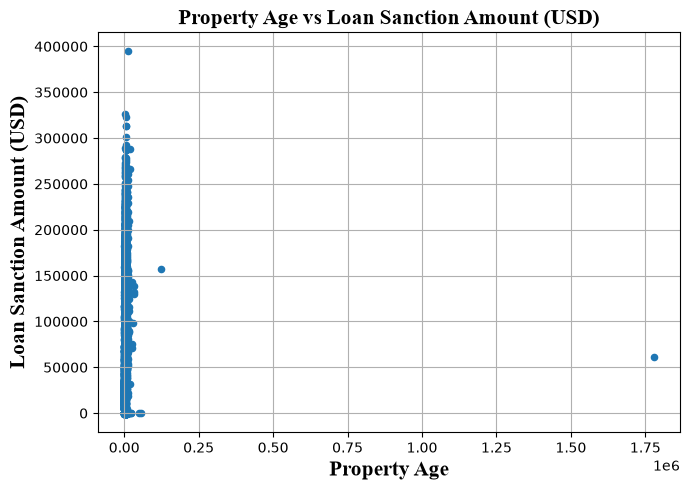

In [8]:
features=[
    "Age",
    "Income (USD)",
    "Loan Amount Request (USD)",
    "Credit Score",
    "Property Age"
]


for feature in features:

    plot_feature_vs_target(
        df,
        feature,
        TARGET
    )

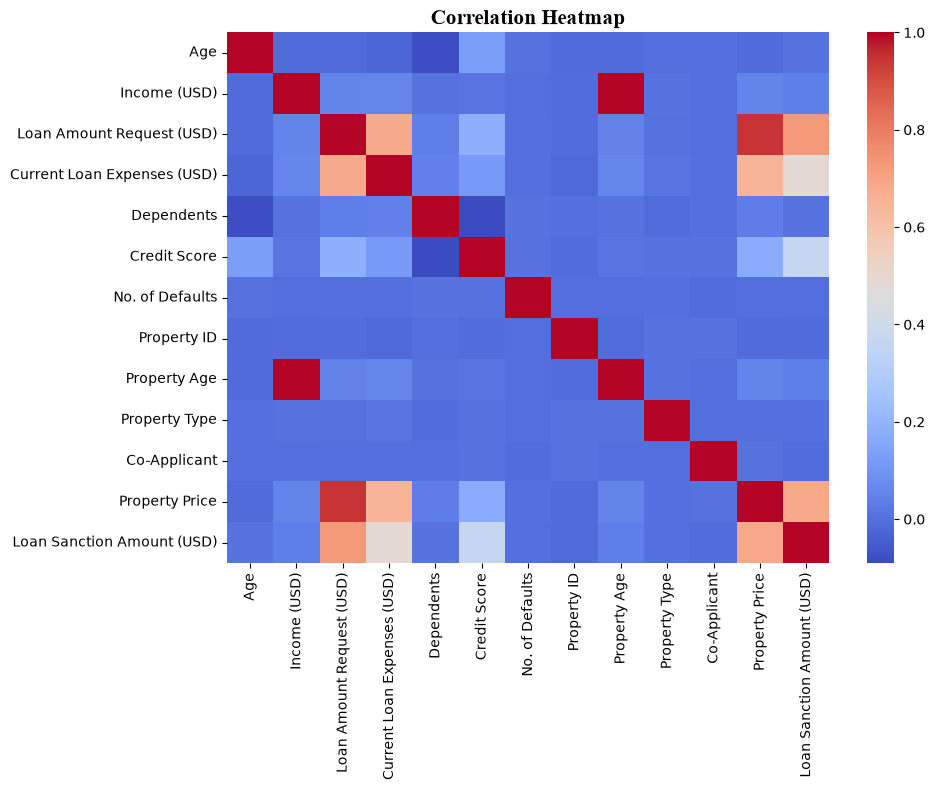

In [9]:
plot_correlation_heatmap(
    df.select_dtypes(include=np.number)
)

In [10]:
DROP_COLUMNS=[
    
    "Customer ID",
    "Name",
    "Property ID"

]
MISSING_VALUES=[
    "?",
    "-999",
    "",
    "NA"
]

In [11]:
(
X_train,
X_test,
y_train,
y_test,
preprocessor,
feature_names

)=preprocess_data(

    df,

    TARGET,

    drop_cols=DROP_COLUMNS,

    missing_values=MISSING_VALUES,

    test_size=0.2

)

In [12]:
print(X_train.shape)
print(X_test.shape)

(23457, 53)
(5865, 53)


In [13]:
linear_model=train_regression(

    X_train,

    y_train,

    algorithm="linear_regression"

)

In [14]:
ridge_model=train_regression(

    X_train,

    y_train,

    algorithm="ridge",

    alpha=1

)

In [15]:
lasso_model=train_regression(

    X_train,

    y_train,

    algorithm="lasso",

    alpha=0.1

)

In [16]:
elastic_model=train_regression(

    X_train,

    y_train,

    algorithm="elastic_net",

    alpha=0.1,

    l1_ratio=0.5

)

In [17]:
models={

    "Linear Regression":
        linear_model,

    "Ridge":
        ridge_model,

    "Lasso":
        lasso_model,

    "Elastic Net":
        elastic_model

}

In [18]:
ridge_best,ridge_params,ridge_score,ridge_results=tune_regression_model(

    X_train,

    y_train,

    algorithm="ridge"

)


print(ridge_params)
print(ridge_score)

{'alpha': 100}
0.5923027104304


In [19]:
lasso_best,lasso_params,lasso_score,lasso_results=tune_regression_model(

    X_train,

    y_train,

    algorithm="lasso"

)

print(lasso_params)
print(lasso_score)

{'alpha': 10}
0.5920861849666709


In [20]:
elastic_best,elastic_params,elastic_score,elastic_results=tune_regression_model(

    X_train,

    y_train,

    algorithm="elastic_net"

)

print(elastic_params)
print(elastic_score)

{'alpha': 0.1, 'l1_ratio': 0.8}
0.5939230668688749


In [21]:
models={

"Linear Regression":linear_model,

"Ridge":ridge_best,

"Lasso":lasso_best,

"Elastic Net":elastic_best

}

In [22]:
performance_table=compare_regression_models(

    models,

    X_test,

    y_test

)


performance_table

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,20754.887368,8.950289e+08,29917.033589,0.602091
1,Ridge,20768.962336,8.952998e+08,29921.561459,0.601970
2,Lasso,20737.559059,8.942462e+08,29903.949315,0.602439
3,Elastic Net,20871.535130,9.000432e+08,30000.720741,0.599862


In [23]:
performance_table.to_csv(
    "../figures/test_performance.csv",
    index=False
)

In [24]:
cv_results=compare_cross_validation(

    models,

    X_train,

    y_train,

    folds=5

)


cv_results

5-FOLD CROSS VALIDATION PERFORMANCE
               Model           MAE           MSE          RMSE  R2 Score  \
0  Linear Regression  21103.769300  9.482386e+08  30788.170584  0.594662   
1              Ridge  21108.407311  9.465063e+08  30760.807273  0.595402   
2              Lasso  21081.063952  9.458374e+08  30750.041511  0.595688   
3        Elastic Net  21175.966664  9.474601e+08  30777.019906  0.594999   

   Training Error  Validation Error  
0    9.388075e+08      9.482386e+08  
1    9.396158e+08      9.465063e+08  
2    9.392574e+08      9.458374e+08  
3    9.425386e+08      9.474601e+08  


,Model,MAE,MSE,RMSE,R2 Score,Training Error,Validation Error
0,Linear Regression,21103.769300,9.482386e+08,30788.170584,0.594662,9.388075e+08,9.482386e+08
1,Ridge,21108.407311,9.465063e+08,30760.807273,0.595402,9.396158e+08,9.465063e+08
2,Lasso,21081.063952,9.458374e+08,30750.041511,0.595688,9.392574e+08,9.458374e+08
3,Elastic Net,21175.966664,9.474601e+08,30777.019906,0.594999,9.425386e+08,9.474601e+08


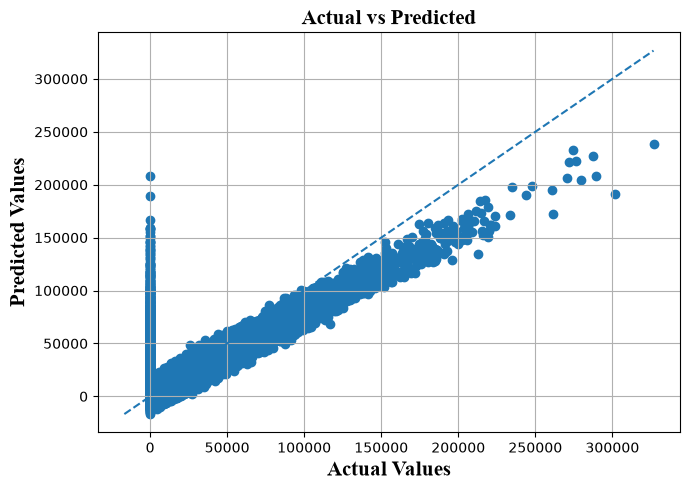

In [25]:
best_model=elastic_best


prediction=best_model.predict(
    X_test
)


plot_actual_vs_predicted(

    y_test,

    prediction

)

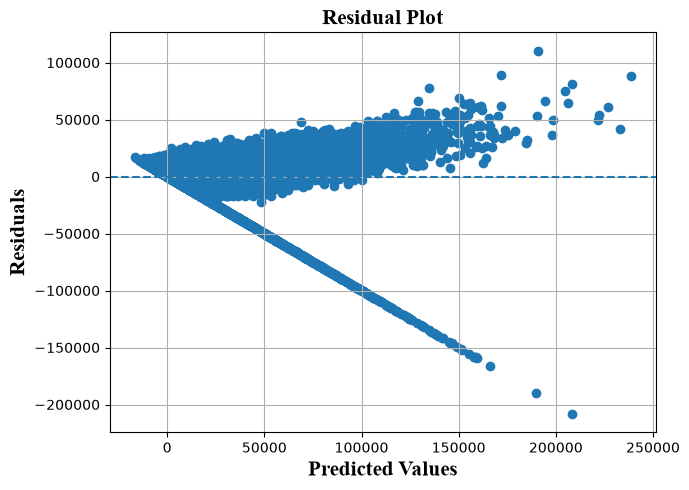

In [26]:
plot_residuals(

    y_test,

    prediction

)

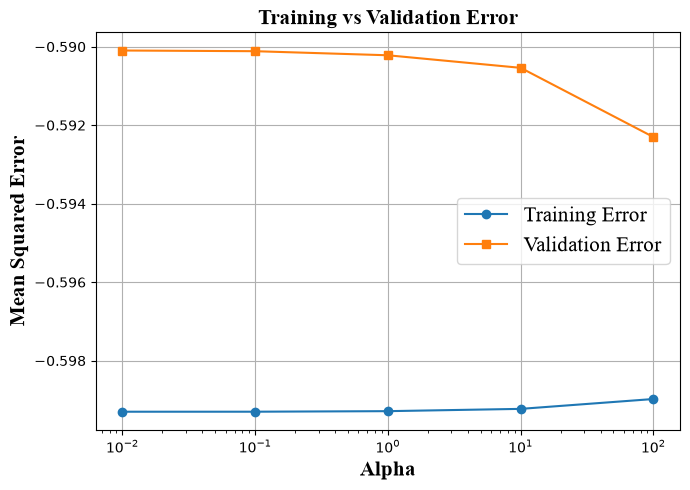

In [27]:
results=pd.DataFrame(ridge_results)


plot_training_validation_error(

    results["param_alpha"],

    -results["mean_train_score"],

    -results["mean_test_score"]

)

In [28]:
linear_coef=get_coefficients(
    linear_model,
    feature_names
)


ridge_coef=get_coefficients(
    ridge_best,
    feature_names
)


lasso_coef=get_coefficients(
    lasso_best,
    feature_names
)


elastic_coef=get_coefficients(
    elastic_best,
    feature_names
)

In [29]:
coef_table=pd.DataFrame({

"Feature":feature_names,

"Linear":
linear_model.coef_,

"Ridge":
ridge_best.coef_,

"Lasso":
lasso_best.coef_,

"Elastic Net":
elastic_best.coef_

})


coef_table.head()

,Feature,Linear,Ridge,Lasso,Elastic Net
0,Age,-589.089128,-558.666403,-553.762337,-540.015913
1,Income (USD),31491.864074,615.807063,27.084186,144.584001
2,Loan Amount Request (USD),34691.844258,33207.526036,34499.896471,29206.396118
3,Current Loan Expenses (USD),-956.912852,-771.420445,-910.776313,-223.100087
4,Dependents,-55.120408,-54.686101,-42.032269,-52.650639


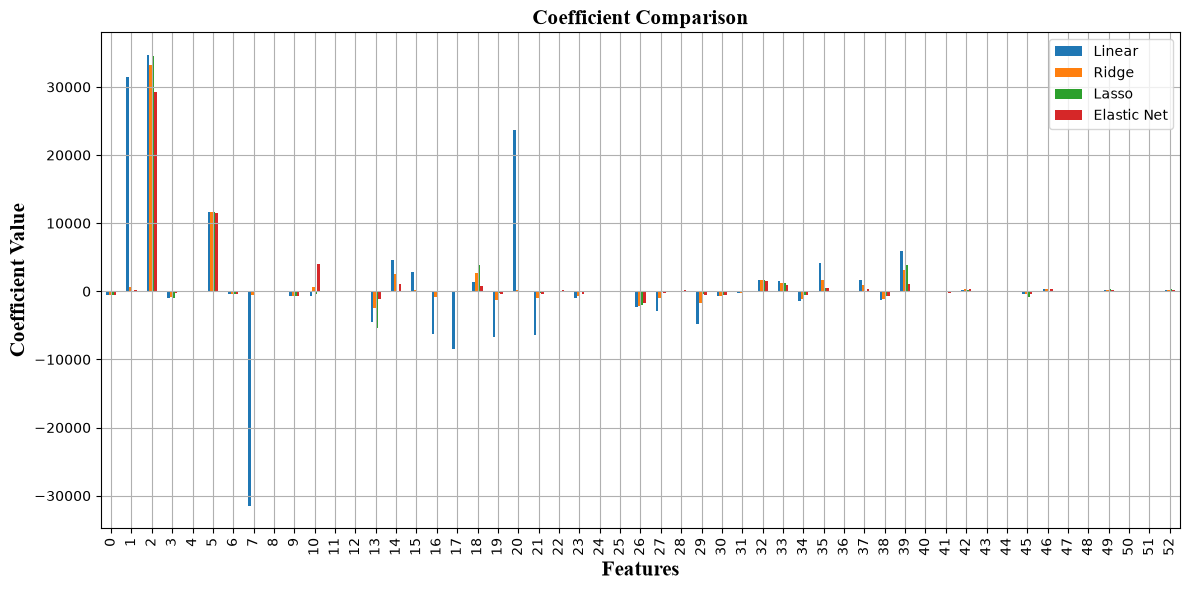

In [30]:
plot_coefficients(
    coef_table
)

In [31]:
time_table=compare_training_prediction_time(

    models,

    X_train,

    y_train,

    X_test

)


time_table

TRAINING AND PREDICTION TIME COMPARISON
               Model  Training Time  Prediction Time
0              Ridge       0.033307         0.002269
1  Linear Regression       0.079897         0.001616
2              Lasso       0.930933         0.001424
3        Elastic Net       2.018575         0.001486


,Model,Training Time,Prediction Time
0,Ridge,0.033307,0.002269
1,Linear Regression,0.079897,0.001616
2,Lasso,0.930933,0.001424
3,Elastic Net,2.018575,0.001486


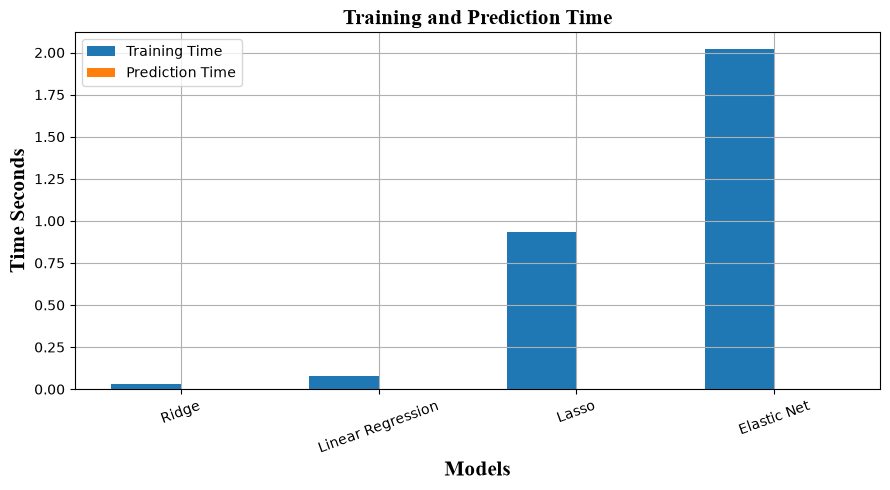

In [32]:
plot_regression_time(

    time_table["Model"],

    time_table["Training Time"],

    time_table["Prediction Time"]

)

In [33]:
performance_table

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,20754.887368,8.950289e+08,29917.033589,0.602091
1,Ridge,20768.962336,8.952998e+08,29921.561459,0.601970
2,Lasso,20737.559059,8.942462e+08,29903.949315,0.602439
3,Elastic Net,20871.535130,9.000432e+08,30000.720741,0.599862
